# EDA — Smart eCommerce Intelligence Pipeline

Load `data/processed/cleaned_products.parquet` or `features.parquet` and explore distributions, KPIs, and first charts for the report.

In [3]:
import pandas as pd
from pathlib import Path

DATA = Path("../data")
processed = DATA / "processed"
df = pd.read_parquet(processed / "cleaned_products.parquet") if (processed / "cleaned_products.parquet").exists() else pd.DataFrame()
df.shape

(220, 15)

Cleaned products: (220, 15)
Features table: (220, 25)

Columns: ['source_platform', 'shop_name', 'product_id', 'product_url', 'title', 'description', 'category', 'brand', 'price', 'old_price', 'availability', 'rating', 'review_count', 'geography', 'scraped_at']

Sample cleaned products:


,source_platform,shop_name,product_id,product_url,title,description,category,brand,price,old_price,availability,rating,review_count,geography,scraped_at
0,shopify,Ruggable,verena-dark-wood-tufted-rug?size=6x9&system=ru...,https://ruggable.com/products/verena-dark-wood...,Verena Dark Wood Rug\n\n4103 Reviews\n\n$119 -...,,NaN,Ruggable,NaN,NaN,NaN,NaN,0,None,2026-03-11T11:16:39.139740+00:00
1,shopify,Ruggable,scalamandre-zebras-red-tufted-rug?size=6x9&sys...,https://ruggable.com/products/scalamandre-zebr...,NEW,,NaN,Ruggable,NaN,NaN,NaN,NaN,0,None,2026-03-11T11:16:39.139740+00:00
2,shopify,Ruggable,calabria-black-multicolor-tufted-rug,https://ruggable.com/products/calabria-black-m...,+3,,NaN,Ruggable,NaN,NaN,NaN,NaN,0,None,2026-03-11T11:16:39.139740+00:00
3,shopify,Ruggable,calabria-coral-multicolor-tufted-rug?size=6x9&...,https://ruggable.com/products/calabria-coral-m...,Calabria Coral Multicolor Rug\n\n117 Reviews\n...,,NaN,Ruggable,NaN,NaN,NaN,NaN,0,None,2026-03-11T11:16:39.139740+00:00
4,shopify,Ruggable,prisma-monochrome-tufted-rug?size=6x9&system=r...,https://ruggable.com/products/prisma-monochrom...,Prisma Monochrome Rug\n\n35 Reviews\n\n$119 - ...,,NaN,Ruggable,NaN,NaN,NaN,NaN,0,None,2026-03-11T11:16:39.139740+00:00



Numeric description (features):


,price,old_price,rating,review_count,discount_pct,price_zscore_by_category,rating_weighted_reviews,description_length,title_length,shop_product_count,category_frequency,popularity_proxy
count,128.000000,70.000000,128.0,220.0,220.000000,2.200000e+02,220.0,220.000000,220.000000,220.000000,71.000000,220.000000
mean,1814.796875,1885.428571,0.0,0.0,0.048417,1.009294e-18,0.0,470.100000,46.709091,112.945455,17.901408,0.007263
std,2163.861314,2372.701821,0.0,0.0,0.082986,5.056756e-01,0.0,684.083581,33.781826,17.797869,11.829932,0.012448
min,0.000000,649.000000,0.0,0.0,0.000000,-9.916922e-01,0.0,0.000000,2.000000,92.000000,4.000000,0.000000
25%,649.000000,749.000000,0.0,0.0,0.000000,0.000000e+00,0.0,0.000000,31.500000,92.000000,7.000000,0.000000
50%,1149.000000,1398.000000,0.0,0.0,0.000000,0.000000e+00,0.0,366.000000,47.000000,128.000000,12.000000,0.000000
75%,1999.000000,2149.000000,0.0,0.0,0.108878,0.000000e+00,0.0,634.000000,57.000000,128.000000,31.000000,0.016332
max,15500.000000,18129.000000,0.0,0.0,0.500200,3.766567e+00,0.0,5487.000000,336.000000,128.000000,31.000000,0.075030



Top categories (cleaned):


category
combos         31
cheesonings    12
accessories     7
hats            7
outlaws         6
dip mixes       4
merchandise     4
Name: count, dtype: int64


Products per shop:


shop_name
Dan-O's Seasoning    128
Ruggable              92
Name: count, dtype: int64


Top categories by average popularity proxy:


category
merchandise    0.037515
cheesonings    0.017993
combos         0.012625
accessories    0.000000
dip mixes      0.000000
hats           0.000000
outlaws        0.000000
Name: popularity_proxy, dtype: float64

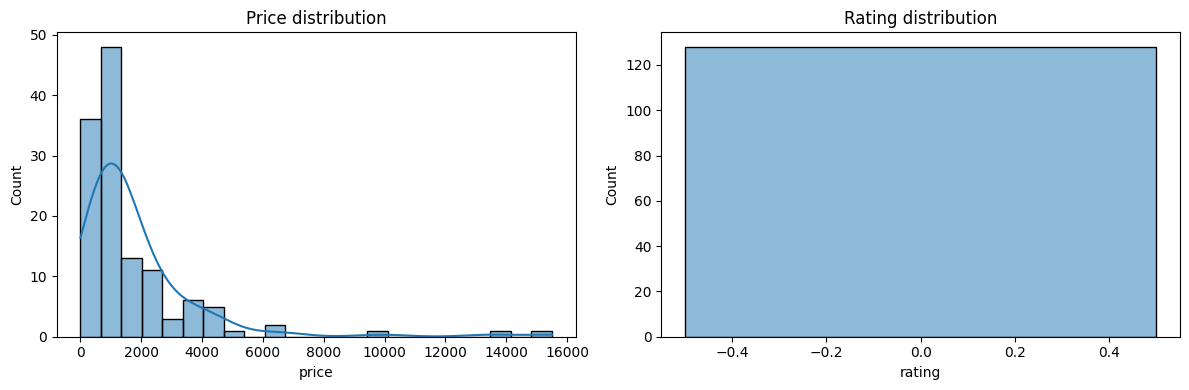

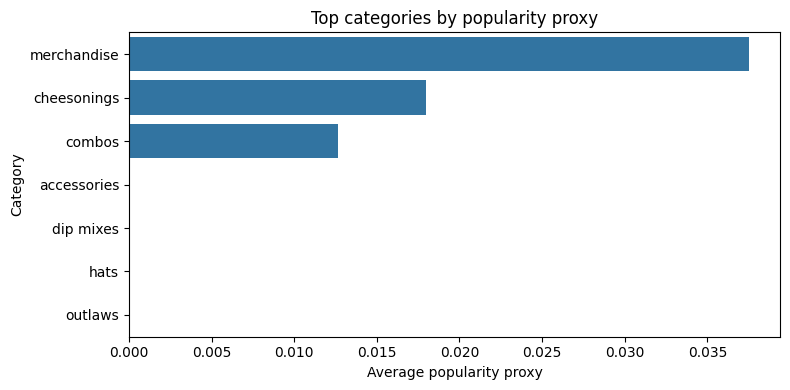

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline

# Load features table (if available)
features_path = processed / "features.parquet"
if features_path.exists():
    df_feat = pd.read_parquet(features_path)
else:
    df_feat = pd.DataFrame()

print("Cleaned products:", df.shape)
print("Features table:", df_feat.shape)

# ---- Basic overview ----
print("\nColumns:", list(df.columns))
print("\nSample cleaned products:")
display(df.head())

# ---- Descriptive stats (numeric) ----
if not df_feat.empty:
    print("\nNumeric description (features):")
    display(df_feat.describe())

# ---- Category distribution ----
if "category" in df.columns:
    print("\nTop categories (cleaned):")
    display(df["category"].value_counts().head(10))

# ---- Shop distribution ----
if "shop_name" in df.columns:
    print("\nProducts per shop:")
    display(df["shop_name"].value_counts())

# ---- Price and rating distributions ----
if not df_feat.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    if "price" in df_feat.columns:
        sns.histplot(df_feat["price"].dropna(), ax=axes[0], kde=True)
        axes[0].set_title("Price distribution")

    if "rating" in df_feat.columns:
        sns.histplot(df_feat["rating"].dropna(), ax=axes[1], kde=True)
        axes[1].set_title("Rating distribution")

    plt.tight_layout()

# ---- Popularity proxy by category (optional) ----
if not df_feat.empty and {"category", "popularity_proxy"}.issubset(df_feat.columns):
    pop_by_cat = (
        df_feat.groupby("category")["popularity_proxy"].mean().sort_values(ascending=False).head(10)
    )
    print("\nTop categories by average popularity proxy:")
    display(pop_by_cat)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=pop_by_cat.values, y=pop_by_cat.index)
    plt.title("Top categories by popularity proxy")
    plt.xlabel("Average popularity proxy")
    plt.ylabel("Category")
    plt.tight_layout()

## Notes for report (Phase 3.3)

- **Data volume:** 220 products in total, coming from **2 shops** (`Ruggable` with 92 products and `Dan-O's Seasoning` with 128 products). The cleaned table has 15 base columns that match the `ProductRecord` schema.

- **Price distribution:** Prices (available for the WooCommerce products) are **highly skewed**. The median price is around **1 149** while a few bundles go up to about **15 500**, which creates a long right tail. Most products are in the low to mid price range.

- **Ratings / reviews:** In this first iteration, **ratings and review counts are effectively zero or missing for all products**, so user engagement cannot be modeled directly. This motivates the use of engineered proxy features (discount, stock, category competitiveness) instead of raw ratings.

- **Category profile:** We observe **7 main categories**: `combos`, `cheesonings`, `accessories`, `hats`, `outlaws`, `dip mixes`, and `merchandise`. `combos` and `cheesonings` are the largest groups, while categories like `dip mixes` and `merchandise` have fewer products but still contribute to the catalog.

- **Popularity proxy:** Using the engineered `popularity_proxy` (combining rating, review count, stock status, and discount), the top categories by average score are **`merchandise`**, followed by **`cheesonings`** and **`combos`**. In this dataset the proxy is mainly driven by discounts and stock, since ratings are not informative yet.

- **Data quality points:**
  - Duplicates are removed using (`source_platform`, `shop_name`, `product_id`) so each product appears once.
  - Shopify products (Ruggable) currently lack detailed numeric fields such as price and rating, while WooCommerce products (Dan-O's Seasoning) are richer thanks to the Store API.
  - Missing string fields like `category`, `brand`, and `availability` are normalized and filled with safe defaults, and numeric columns are coerced carefully so that preprocessing and feature engineering remain robust.

These points feed directly into the "Data prep + feature engineering" and "Experiments & evaluation" sections of the written report.